# Welcome to lkdata!

lkdata is a python package designed to handle time-series data transformations using the built-in power of [pandas](https://pandas.pydata.org/). lkdata serves at the backend for lightkurve v3. lightkurve users will typically not interact with lkdata directly. However, they are used for the affiliated packages to process [Lightcurve](https://archive.stsci.edu/missions/tess/doc/EXP-TESS-ARC-ICD-TM-0014.pdf#page=32) (LC), [Target Pixel File](https://archive.stsci.edu/missions/tess/doc/EXP-TESS-ARC-ICD-TM-0014.pdf#page=24) (TPF), and [Full Frame Image](https://archive.stsci.edu/missions/tess/doc/EXP-TESS-ARC-ICD-TM-0014.pdf#page=18) (FFI) [data](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) for the [TESS](https://tess.mit.edu) and [Kepler/K2](https://science.nasa.gov/mission/kepler/) missions. 

In this notbook, we will cover the basic properties of lkdata, as well as examples of how to use the built-in functionality. 

lkdata has three main classes to deal with data of different shapes and properties.
- Timeseries (such as LC) data is handled by DataSeries, BoolSeries, or BitwiseSeries depending on the data type (more on that in section 1 below)
- 3-dimensional data (such as TPF or FFI time series) are handled by DataCube
- Collections of timeseries-like arrays with shared times can be handled by SeriesCollection, BoolCollection, or BitwiseCollection. 

All of these data products require at a minimum some sort of temporal data (time, cadence number, etc) and data associated with those times. Errors associated with the data are also supported. When performing math operations on the data, such as adding, subtracting, or multiplying, these associated errors are handled appropriately (e.g., errors are automatically added in quadrature). 

A mixture of any of these types of data can be bundled in a single lkdata DataSet class, provided they all have the same times associated with them. The advantage of the DataSet is that operations applied to the DataSet, such as binning or slicing, are applied to all associated Series, Frame, and Cube objects as appropriate. For example, you could bundle a group of DataSeries that each represent a single source of flux (simple aperture flux, corrected flux, background flux, etc) and simulataneously cutout a time range of interest. We will see more applications for DataCubes in the examples throughout this notebook. 

We start by introducing the data classes using abstract data in sections 1 and 2. If you are mainly concerned with how this can be applied to real data, please skip ahead to section 3 where we demonstrate how these classes can be applied to TESS data. 

In [1]:
# Import all of the packages we will use throughout this notebook
import sys
import os
parent_dir_name = os.path.dirname(os.path.dirname(os.path.dirname(os.path.realpath('lkdata'))))
sys.path.append(parent_dir_name + "/src")
import lkdata
import lksearch
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
print(lkdata.__path__)

['/Users/nthom/TESS_GI/gitNschanch/tessgi/lkdata/src/lkdata']


# 1 - Handling 1-Dimensional timeseries data

Data arrays that are associated with time values can be represented by one of three different classes: DataSeries, BoolSeries, or BitwiseSeries. DataSeries represent any numerical data that varies with time, such as flux, energy, or other lightcurve-like data. BoolSeries handle any Boolean data that varies by time, such as a Boolean mask for time steps that are 'good' or 'bad'. Finally, BitwiseSeries handle data that represents bitwise information. This was motivated by the [TESS](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview#id-2.0-DataProductOverview-Table:CadenceQualityFlags), [Kepler, and K2](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/k2/_documents/MAST_Kepler_Archive_Manual_2020.pdf#page=18) quality masks, which use bitwise AND operations to represent different combinations of data quality flags. 

The DataSeries structure allows us to manipulate the data in a number of ways, including binning by time, slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section 3 below. 


### 1.1 DataSeries

The DataSeries object can be used to represent any series of numerical data that varies by time. Time in this case can be in any unit (days, BJD, UTC, hours, etc), but must be sorted from the first time step to the last time step. In this case below, we create a random time array, which could for example represent days since the start of the observation. 

In [2]:
# Generate some random times. 
times = np.linspace(0, 24, 120)

# Generate some random data
data = np.random.randn(len(times))

# Generate some errors
data_err = np.abs(data) * .1

All lkdata products require at a minimum some sort of data and an associated time. Multiple time indices are allowed (e.g. BJD, UTC, delta time, etc), but only a single data product is allowed. Associated uncertainties are optional. You can bundle multiple objects together using a DataSet. For more information on bundling, see section 4 below. 

In [9]:
# TODO: can you give 'data' a keyword so there is a column label? Dictionary just doesn't work at all, but docs say it should
# TODO: Index=times looks like it should work in the docs, but doesn't
#       Docstring in general just inaccurate. time_indices not listed and index is confusing
# TODO: can't have the metadata be called 'name' as that is a reserved pandas thing


# Create a DataSeries object with data, associated uncertainties, and time information, and extra 'metadata'
series = lkdata.DataSeries(data=data, #dict(zip(times, data)),
                       uncertainty=data_err,
                       time_indices={'time':times, 'offset_time':times+200},
                       extra_metadata = 'This is my first DataSeries', 
                    #index=times,
                          )
series

time_index  time       offset_time
0           0.000000   200.000000    -0.444383
1           0.201681   200.201681    -0.408639
2           0.403361   200.403361    -0.682636
3           0.605042   200.605042     1.052871
4           0.806723   200.806723     1.980900
                                        ...   
115         23.193277  223.193277     0.739094
116         23.394958  223.394958     0.228672
117         23.596639  223.596639     0.161113
118         23.798319  223.798319    -2.132134
119         24.000000  224.000000     0.214622
Length: 120, dtype: float64


📉 DataSeries (120,)

Great, we've initialized our first DataSeries! The representation of the object is very similar to a pandas DataFrame. The above cell shows that this is a DataSeries object with a length of 120. All time columns are included as a [MultiIndex](https://pandas.pydata.org/docs/user_guide/advanced.html). The uncertainties are not shown in the default [repr](https://docs.python.org/3/library/functions.html#repr), but you can see they are there using describe_series(), as shown below.

In [10]:
series.describe_series()

📉 DataSeries (120,) (120,) (ntime)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120,))

Time indices available: ['time_index', 'time', 'offset_time']
	time_index     :	[  0   1 ... 118 119]
	time           :	[ 0.          0.20168067 ... 23.79831933 24.        ]
	offset_time    :	[200.         200.20168067 ... 223.79831933 224.        ]

User defined attributes accessible via `object.key`
(displaying only unique values)
	extra_metadata :	This is my first DataSeries


Note that there is now a keyword called 'time_index' that has been added to the multiindex. This is a unique array of index values that is automatically added when initializing a new DataSeries. You can access the different time arrays by using their keynames. 

In [11]:

print(series.time_index)
print(series.time)


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]
[ 0.          0.20168067  0.40336134  0.60504202  0.80672269  1.00840336
  1.21008403  1.41176471  1.61344538  1.81512605  2.01680672  2.21848739
  2.42016807  2.62184874  2.82352941  3.02521008  3.22689076  3.42857143
  3.6302521   3.83193277  4.03361345  4.23529412  4.43697479  4.63865546
  4.84033613  5.04201681  5.24369748  5.44537815  5.64705882  5.8487395
  6.05042017  6.25210084  6.45378151  6.65546218  6.85714286  7.05882353
  7.2605042   7.46218487  7.66386555  7.86554622  8.06722689  8.26890756
  

### 1.2 BoolSeries

Creating a BoolSeries is very similar to creating a DataSeries. The main difference is that the data is now a boolean array. We will create one my making a boolean array based on the random data generated in Section 1.1.

In [12]:
# Create a boolean array based on the data values
mask = data > 0
print(mask)

[False False False  True  True  True False  True  True False  True  True
 False  True False False False False  True False False  True False  True
 False  True  True  True False False False False  True False False  True
  True False False  True  True  True  True  True  True False  True False
 False  True False  True  True False  True  True  True  True False  True
 False False  True False  True False False False  True  True False False
 False False  True  True  True False  True False  True  True  True False
  True  True  True  True  True  True  True False  True  True  True  True
  True  True  True  True  True False  True False False False  True  True
 False False False False False  True  True  True  True  True False  True]


In [13]:
boolseries = lkdata.BoolSeries(data=mask,
                        uncertainty = data_err,
                       time_indices={'time':times},
                        meta={'name':'myboolseries',}
                          )
boolseries.describe_series()

⚫️⚪️ BoolSeries (120,) (120,) (ntime)


Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

User defined attributes accessible via `object.key`
(displaying only unique values)
	uncertainty :	[0.04443827 0.04086387 ... 0.21321341 0.0214622 ]
	meta        :	{'name': 'myboolseries'}


And just like that we have a BoolSeries! In this case, we assigned an uncertainty value as we did for the DataSeries. However, the data description shows that the uncertainty values are considered defined attributes, not true Uncertainty values. This is because uncertainties do not apply to Boolean values in the same way. Modifying the BoolSeries with not apply to these values, and they are treated strictly as additional metadata. 

### 1.3 Manipulating DataSeries data

Once you have a Series object, you can manipulate it in various ways. Common actions you might make include slicing or binning the data. 


#### 1.3.1 - time downsampling 
In the cell below, we demonstrate time binning. In lkdata, this is known as downsampling. By default, this combines 5 time steps. However, you can choose other time steps by specifying nframes=X. Currently, lkdata only allows for summing the data within time bins (with errors added in quadrature). 

TODO: Allow for other combination methods (mean and median)
TODO: Does it allow for a sliding window?

In [14]:
# Generate some random times. In this case, add a gap in time, with different time steps before and after the gap.
times = np.append(np.linspace(0, 24, 120), np.linspace(26,40, 120))

# Generate some random data
data = np.random.randn(len(times))

# Generate some errors
data_err = np.abs(data) * .1

series = lkdata.DataSeries(data=data, 
                       uncertainty=data_err,
                       time_indices={'time':times, 'offset_time':times+200},
                       extra_metadata = 'This is a random DataSeries', 
                          )
series

time_index  time       offset_time
0           0.000000   200.000000     0.728719
1           0.201681   200.201681     0.804078
2           0.403361   200.403361    -0.562059
3           0.605042   200.605042    -0.446671
4           0.806723   200.806723     0.266377
                                        ...   
235         39.529412  239.529412    -1.067081
236         39.647059  239.647059    -2.098681
237         39.764706  239.764706    -1.521621
238         39.882353  239.882353     0.620270
239         40.000000  240.000000     0.654927
Length: 240, dtype: float64


📉 DataSeries (240,)

In [15]:
# TODO - check when downsample allows specifying time bins

print(f"The series has shape {series.shape}")
downsampled_series = series.downsample(level='time') # default 5 time steps
print(f"The downsampled series has shape {downsampled_series.shape}")
print(' ')
downsampled_series

The series has shape (240,)
The downsampled series has shape (24,)
 
mid_index  indices                time       offset_time
2.0        [0 1 2 3 4]            0.403361   200.403361     0.790444
7.0        [5 6 7 8 9]            1.411765   201.411765     0.271712
12.0       [10 11 12 13 14]       2.420168   202.420168    -2.979803
17.0       [15 16 17 18 19]       3.428571   203.428571    -0.789850
22.0       [20 21 22 23 24]       4.436975   204.436975    -0.989379
                                                              ...   
97.0       [95 96 97 98 99]       19.563025  219.563025     0.508268
102.0      [100 101 102 103 104]  20.571429  220.571429     0.299001
107.0      [105 106 107 108 109]  21.579832  221.579832     1.011485
112.0      [110 111 112 113 114]  22.588235  222.588235     0.048849
117.0      [115 116 117 118 119]  23.596639  223.596639    -0.150981
Length: 24, dtype: float64


📉 DataSeries (24,)

In this case, the size of the time steps changed before and after the 'gap' in time. Downsample can handle gaps in time, but does expect uniform time steps when time data is available. In this case, only data before the gap is binned (you can see this by looking at the index values and length of downsampled_series from the cell above). 

You can force binning of the data by specifying level='time_index'. This forces downsample to use the index values rather than the time values themselves. The downside of this is that the bins before and after the gap have different effective exposure times.

In [16]:
downsampled_series = series.downsample(level='time_index') # default 5 time_index steps
print(f"The series has shape {series.shape}")
print(f"The downsampled series has shape {downsampled_series.shape}")
downsampled_series

The series has shape (240,)
The downsampled series has shape (48,)
mid_index  indices                time       offset_time
2.0        [0 1 2 3 4]            0.403361   200.403361     0.790444
7.0        [5 6 7 8 9]            1.411765   201.411765     0.271712
12.0       [10 11 12 13 14]       2.420168   202.420168    -2.979803
17.0       [15 16 17 18 19]       3.428571   203.428571    -0.789850
22.0       [20 21 22 23 24]       4.436975   204.436975    -0.989379
                                                              ...   
217.0      [215 216 217 218 219]  37.411765  237.411765     3.643300
222.0      [220 221 222 223 224]  38.000000  238.000000     0.434148
227.0      [225 226 227 228 229]  38.588235  238.588235     0.642706
232.0      [230 231 232 233 234]  39.176471  239.176471     0.795529
237.0      [235 236 237 238 239]  39.764706  239.764706    -3.412186
Length: 48, dtype: float64


📉 DataSeries (48,)

#### 1.3.2 - slicing

DataSeries objects can be easily sliced in the same manner you [slice numpy arrays](https://numpy.org/doc/stable/user/absolute_beginners.html#indexing-and-slicing). In the example below we slice every other sample from the first 100 time steps in the DataSeries.

In [17]:
sliced_series = series[:100:2]
print(f"The series has shape {series.shape}")
print(f"The series after slicing has shape {sliced_series.shape}")
sliced_series

The series has shape (240,)
The series after slicing has shape (50,)
time_index  time       offset_time
0           0.000000   200.000000     0.728719
2           0.403361   200.403361    -0.562059
4           0.806723   200.806723     0.266377
6           1.210084   201.210084     0.652089
8           1.613445   201.613445    -0.151322
                                        ...   
90          18.151261  218.151261    -0.773286
92          18.554622  218.554622    -0.577042
94          18.957983  218.957983     0.488511
96          19.361345  219.361345     0.343842
98          19.764706  219.764706     0.188179
Length: 50, dtype: float64


📉 DataSeries (50,)

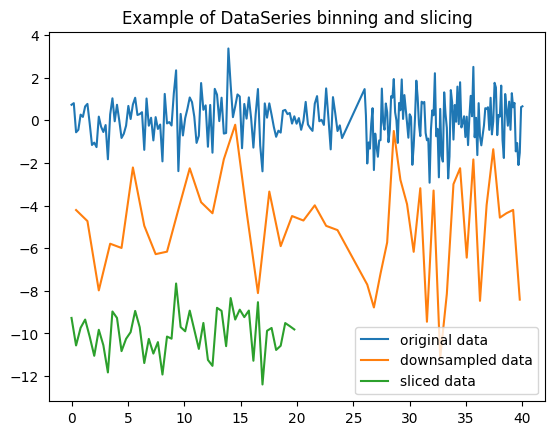

In [18]:
# Let's take a look at what these DataSeries look like
fig, ax = plt.subplots(1)
ax.set_title('Example of DataSeries binning and slicing')
ax.plot(series.time, series.data, label='original data')
# Note we are artificially adding a y-offset to the data for clarity
ax.plot(downsampled_series.time, downsampled_series.data - 5,label='downsampled data') # bin 5 datapoints
ax.plot(sliced_series.time, sliced_series.data - 10, label='sliced data') # First 100 time steps, keeping every other step
ax.legend()
plt.show()

## 2 - Handling 2-Dimensional timeseries data

Now let's take a look at timseries of 2-D images. lkdata handles this type of data with the DataCube class. For TESS, Kepler, and K2 data, this would be the data structure used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section 3 below. 


### 2.1 creating a DataCube

In [19]:
# Generate some random times. 
times = np.linspace(0, 24, 120)

# Generate some random data
data = np.random.randn(len(times), 5,7)

# Generate some errors
data_err = np.abs(data) * .1


In [20]:
# print out the first 'image'
data[0,:,:], data_err[0,:,:]

(array([[ 0.26479527, -0.7176554 ,  1.19352481,  0.96288568, -1.39761591,
          0.90516058,  1.30862242],
        [ 2.9078104 ,  0.5498973 , -0.28956965, -0.67776628, -1.85327314,
         -0.78587257,  0.43078148],
        [-0.89549298, -1.35759282,  1.01606045, -0.11913767, -0.86197555,
          0.17377762,  0.4212068 ],
        [ 1.1451829 ,  0.5093124 ,  0.69421882,  0.72563959,  1.54178296,
          0.60653945, -1.33073935],
        [-1.68051547, -0.4193273 , -0.39215571,  0.18697809, -1.67051234,
          1.13202874,  0.91768864]]),
 array([[0.02647953, 0.07176554, 0.11935248, 0.09628857, 0.13976159,
         0.09051606, 0.13086224],
        [0.29078104, 0.05498973, 0.02895697, 0.06777663, 0.18532731,
         0.07858726, 0.04307815],
        [0.0895493 , 0.13575928, 0.10160605, 0.01191377, 0.08619755,
         0.01737776, 0.04212068],
        [0.11451829, 0.05093124, 0.06942188, 0.07256396, 0.1541783 ,
         0.06065394, 0.13307393],
        [0.16805155, 0.04193273, 0.0

In [21]:
print(times.shape, data.shape, data_err.shape)

(120,) (120, 5, 7) (120, 5, 7)


We have now generated the data needed to make a DataCube. In this example, we are making a timeseries with 120 time steps. We also have a 2-dimentional data product for each of these times steps. We can now put this information into our DataCube object. 

In [22]:
cube = lkdata.DataCube(data=data,
                       uncertainty=data_err,
                       time_indices={'time':times},
                       meta="My first DataCube")

In [23]:
cube

📘 DataCube (120, 5, 7), Uncertainty: True

Great! You can see that when we call the cube object, we get a basic summary of the contents. This tells us the shape of the cube and whether there are uncertainties associated with the data. It also shows a visualization of the data contained in the first time step.

We can get more information about the data contained in the Cube by calling describe_cube()

In [24]:
cube.describe_cube()

📘 DataCube (120, 5, 7), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (120, 35)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 5, 7))

Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

Number of unique 'series': 35

Row names: ['row']
	row         :	[0 0 ... 4 4]

Column names: ['col']
	col         :	[0 1 ... 5 6]

User defined attributes accessible via `object.key`
(displaying only unique values)
	meta        :	My first DataCube


### 2.2 Manipulating DataCubes

As with the DataSeries, you can manipulate the data cubes by slicing or binning (either temporally or spatially) the data. We demonstrate these functions in the cells below. 

#### 2.2.1 - Slicing
Now that we have our DataCube set up, we can start manipulating the data as we did for DataSeries objects. 

For example, what if we want only 1 out of every 10 time steps?

In [25]:
sub_cube = cube[::10, :,:] # Slice in the time step dimension
sub_cube

📘 DataCube (12, 5, 7), Uncertainty: True

Or only the last time step?

In [26]:
cube[-1,:,:]

📘 DataCube (1, 5, 7), Uncertainty: True

Or to keep all timesteps for a specific subset of pixels?

In [27]:
sub_cube = cube[:, 1:4,2:5] # Cut out a selection of pixels
sub_cube

📘 DataCube (120, 3, 3), Uncertainty: True

#### 2.1.2 - SeriesCollections

This looks great when slicing contiguous pixels, as we did in the cell above. But what happens when you extract non-contiguous pixels?

In [28]:
sub_cube = cube[:, ::2,::2] # Cut out all time steps for every other pixel
sub_cube.describe_frame()

🟦 SeriesCollection (120, 12) (ntime, nseries)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 3, 4))

Time indices available: ['time_index', 'time']
	time_index :	[  0   1 ... 118 119]
	time       :	[ 0.          0.20168067 ... 23.79831933 24.        ]

Row names: ['row']
	row        :	[0 0 0 0 2 2 2 2 4 4 4 4]

Column names: ['col']
	col        :	[0 2 4 6 0 2 4 6 0 2 4 6]

User defined attributes accessible via `object.key`
(displaying only unique values)
	meta       :	My first DataCube


This looks a little bit different. Since we no longer have contiguous blocks of pixels, this now returns the underlying pandas data frame contianing information on each pixel. Note that in this case you can no longer treat the object as a DataCube with the same functionality as before. Instead the data is handled by the third class, a SeriesCollection, which as the name implies is a collection of individual light curves that we want to treat as a cohesive unit, but are not spatially tied together. 

You are also able to generate your own DataSeriesCollections, as shown in the cell below. 


In [29]:
# Generate some random data for 10 'timeseries' with 120 time steps
data = np.random.randn(120,10)

# Generate some errors
data_err = np.abs(data) * .1

frame = lkdata.DataSeriesCollection(data=data,
                       uncertainty=data_err,
                          )

# TODO: DataFrame repr should also say if there are associated errors. 

frame

series,0,1,2,3,4,5,6,7,8,9
time_index,,,,,,,,,,
0,-0.849361,-0.091021,-0.274475,-0.346033,2.119728,1.114116,-1.354386,0.528156,-0.974410,1.514124
1,0.860636,-0.346311,0.312883,0.741151,-0.169449,-0.877132,0.342592,0.555623,-0.951786,0.356601
2,-0.191363,-0.147917,0.376306,1.599074,1.279543,0.269915,0.317503,-1.597276,-0.622260,-1.327116
3,1.669753,0.997688,-0.441379,-0.899863,0.462450,-0.823922,0.345797,0.462294,-0.789691,-2.442910
4,-1.953774,0.267384,0.934929,-0.306772,-1.085419,0.262764,1.100728,-1.957803,0.951280,0.074600
...,...,...,...,...,...,...,...,...,...,...
115,-2.238514,0.762705,-2.885517,0.880503,0.326005,-1.118068,0.139568,-0.557489,-0.617928,-0.932534
116,-0.347664,1.632787,-1.619175,0.662280,-0.889235,-0.759716,-2.080370,-0.103302,0.895139,-0.953365
117,-1.906314,1.694960,-0.341340,-1.688050,-0.194083,-1.397048,2.130303,0.069595,-0.186559,-0.783567


In [33]:
# TODO: describe_frame should be describe_collection I think
# TODO: This repr also breaks as there are no row names. 
frame.describe_frame()

🟦 SeriesCollection (120, 10) (ntime, nseries)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 10))

Time indices available: ['time_index']
	time_index :	[  0   1 ... 118 119]

Row names: None


TypeError: 'NoneType' object is not iterable

### 2.3 Downsampling (binning) by time

Instead of slicing, we may instead want to bin the data in the time dimension. This has the effect of taking the *sum* of each 'pixel' over the specified number of time steps. Note that the uncertaintaies are automatically added in quadrature. 

As with the DataSeries in Section 1.3.1, you can specify the specific value in the time index you want to include. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [36]:
# Downsample every 5 time steps. If nframes is unspecified, 5 is the default value. 
timebin_cube = cube.downsample(nframes=5, level="time")
timebin_cube

📘 DataCube (24, 5, 7), Uncertainty: True

In [37]:
# Verify that the uncertainties were added in quadrature
print(cube.uncertainty[0:5,0,0]) #first 5 uncertainty values for pixel (0,0)
print(timebin_cube.uncertainty[0,0,0]) # first binned uncertainty value for pixel (0,0)

np.sqrt(np.sum(cube.uncertainty[0:5,0,0].array**2))

Uncertainty([0.02647953, 0.16005953, 0.03263863, 0.02991651, 0.14245798])
Uncertainty(0.22039685)


0.22039685128543998

### 2.4 Downsampling (binning) spatially

You are also allowed to spatially downsample DataCube objects. This would create the *sum* of pixels. If you specify "factor={integer}", it will use the same downsample size for column and row. For unevenly sized bins, you are able to sepcify col_factor/row_factor. Column/rows at the edge that do not "fill up" a new bin are discarded. In the case below, this would mean that column 6 and row 4 are discarded in the resulting DataCube object. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [38]:
spacebin_cube = cube.spatial_downsample(factor=2)
spacebin_cube

📘 DataCube (120, 2, 3), Uncertainty: True

In [39]:
spacebin_cube = cube.spatial_downsample(col_factor=3, row_factor=2)
spacebin_cube

📘 DataCube (120, 2, 2), Uncertainty: True

### 2.5 Other Cube Properties

lkdata objects inherit a lot of functionality from pandas objects. For example, you can call mean/median/min/max functions specifying the axis as you would a pandas dataframe. 

Notice in the case below, you get a tuple as a result. The first array returns the max data value for each pixel over the time dimension, while the second array shows the max uncertainty for each pixel over the time dimension. 

In [40]:
cube.max(axis=0)

(array([[3.63244716, 3.17963539, 3.54065522, 2.64201849, 2.35672653,
         2.71336547, 2.52618393],
        [3.99397669, 3.51460824, 2.07289586, 1.84863441, 2.40758159,
         2.16101909, 3.36194385],
        [2.44119144, 3.05282195, 2.57602352, 1.8970638 , 3.02170786,
         3.72700857, 2.36493659],
        [2.35284529, 3.50187251, 2.41819302, 2.78791779, 3.21243593,
         2.30037775, 2.6587634 ],
        [3.25974077, 2.33034392, 2.91439142, 2.35816391, 3.07183244,
         3.0595614 , 3.09337435]]),
 array([[0.30718324, 0.21184276, 0.39939767, 0.32597408, 0.32124359,
         0.35018725, 0.35406552],
        [0.23770849, 0.23510552, 0.25261839, 0.29803408, 0.27133655,
         0.25881498, 0.35146082],
        [0.27879178, 0.30694616, 0.23888242, 0.29143914, 0.21113654,
         0.2418193 , 0.23359594],
        [0.33619438, 0.26420185, 0.36324472, 0.20892027, 0.25140444,
         0.37270086, 0.1651204 ],
        [0.23528453, 0.23559242, 0.27685078, 0.25760235, 0.19713628,
  

In [41]:
cube.min(axis=1)

time_index  time     
0           0.000000    -1.853273
1           0.201681    -2.019892
2           0.403361    -2.679274
3           0.605042    -1.440870
4           0.806723    -1.822191
                           ...   
115         23.193277   -1.567396
116         23.394958   -1.986530
117         23.596639   -2.200535
118         23.798319   -1.703904
119         24.000000   -1.435990
Length: 120, dtype: float64


📉 DataSeries (120,)

TODO: Any other features we should introduce?

# 3 - Example with real TESS data

For TESS, Kepler, and K2 data, the DataCube could hold the data used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we get any further, let's get some data we can use to motivate the different functionality. K2-18 b is a Hycean planet originally found by the K2 mission. Subsequently, this planet has been observed by TESS. Let's download a TPF cutout from the FFI using TESScut using [lksearch](https://github.com/lightkurve/lksearch).

In [42]:
# Search for data we will use to populate our DataCube
results = lksearch.TESSSearch('K2-18', exptime=600).cubedata
results

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,388804061,TESS-SPOC,HLSP,45,600.0,0.0,2021,FITS
1,388804061,TESS-SPOC,HLSP,46,600.0,0.0,2021,FITS
2,"172.56049060233, 7.58840426347",TESScut,TESS Sector 45,45,600.0,0.0,2021,TESS FFI Cutout (sector 45)
3,"172.56049060233, 7.58840426347",TESScut,TESS Sector 46,46,600.0,0.0,2021,TESS FFI Cutout (sector 46)
4,"172.56049060233, 7.58840426347",TESScut,TESS Sector 72,72,200.0,0.0,2023,TESS FFI Cutout (sector 72)


Now that we have a list of available data products, lets download one of them. Specifically let's use [TESScut](https://mast.stsci.edu/tesscut/docs/index.html) to extract a TPF from sector 45.  Further, let's use an uneven size to make the later transformations more clear.

In [45]:
manifest = results[2].download(TESScut_size=(11,9))
manifest

,Local Path,Status
0,/Users/nthom/.lksearch/cache/mastDownload/TESS...,COMPLETE


In [47]:
# Read in our downloaded file using astropy's fits functionality
tpf = fits.open(manifest['Local Path'][0])
tpf

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x17aa023d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x17babc700>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11faca130>]

A DataCube product requires a minimum of two components: a 1-d array containing the time and a 3D array with shape (ntime, nrow, ncol).

We will start by making a simple DataCube object that just contains the time, flux, and flux error information. Note that additional time series information, such as the time correction applied to the data, could also be stored in the Cube.  

In [48]:
time = tpf[1].data['TIME']
timecorr = tpf[1].data['TIMECORR'] #light arrival time correction applied
flux = tpf[1].data['FLUX']#.transpose([0,2,1]) # a TPF has a shape (ntimes, ncol, nrow), so we need to transpose this for our DataCube
flux_err = tpf[1].data['FLUX_ERR']#.transpose([0,2,1])
time.shape, flux.shape, flux_err.shape

((3450,), (3450, 11, 9), (3450, 11, 9))

In this example, in addition to the time values, we will add an additional non-standard time index. Namely, we will add the 'timecorr' value provided in the TPF file. This is an array that contains the light arrival time correction applied by the pipeline at each time step. 

Note that the timecorr array has an additional byteswap().newbyteorder() appended to the end. Occasionally you may have to deal with data that were created on a machine with a different byte order than the one on which you are running Python. Without these lines, you will receive the following error, "ValueError: Big-endian buffer not supported on little-endian compiler". 

In [49]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()},
)

                                   

The DataCube now is storing the flux and error as a pandas dataframe. This allows us to use the built-in feature of pandas, as well as add some useful new properties. 

Let's take a look at the data in more detail. The DataCube is visually represented as a 2-dimensional grid that by default shows the first image in the time series. The data (in this case the raw flux) is shown in the grid, with a grayscale colorbar the allows you to visualize what the image looks like. 

In [50]:
cube

📘 DataCube (3450, 11, 9), Uncertainty: True

That looks like a cube, but perhaps we want to retain the pixel location on the CCD. We can do that by defining the row and column based on the TESS header data. To learn more about what information is stored in the TESS header, you can check out [the data product description document](https://ntrs.nasa.gov/api/citations/20180007935/downloads/20180007935.pdf). 

In [51]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       # Note TESS time by default is the Barycentric Julian Data with an offset of 2457000
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()}, 
                       row_indices={'pixel_row':np.arange(lcf[1].header['2CRV4P'], lcf[1].header['2CRV4P'] + flux.shape[1])},
                       col_indices={'pixel_col':np.arange(lcf[1].header['1CRV4P'], lcf[1].header['1CRV4P'] + flux.shape[2])}
)


cube

📘 DataCube (3450, 11, 9), Uncertainty: True

We can get more information about our newly created DataCube by using the .describe_cube() function. You can see that our DataCube contains 3,450 time steps for the data as well as the uncertainty. There are 3 time indices available including the time in BJD and the time correction used by the pipeline. 

In [52]:
cube.describe_cube()

📘 DataCube (3450, 11, 9), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (3450, 99)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(3450, 11, 9))

Time indices available: ['time_index', 'time', 'timecorr']
	time_index  :	[   0    1 ... 3448 3449]
	time        :	[2459525.50722746 2459525.51417241 ... 2459550.61369164 2459550.62063674]
	timecorr    :	[-0.00325851 -0.003258   ... -0.00094983 -0.00094917]

Number of unique 'series': 99

Row names: ['pixel_row']
	pixel_row   :	[1002 1002 ... 1012 1012]

Column names: ['pixel_col']
	pixel_col   :	[583 584 ... 590 591]

User defined attributes accessible via `object.key`
(displaying only unique values)


### 3.1 - Slicing 

Now that we have a DataCube, we can start to manipulate our data. The nice thing about the DataCube is that it applies your slice to the time, data, and data errors automatically. 

**Note that the rows/columns are trasformed when being stored as a pandas dataframe. However, when you slice, you can slice using [time, row, col]**

You can plot the DataCube in a 'lightkurve-like' way using matplotlib.imshow(). This example in the cell below plots the first time step. Note we have to set the extent to display the row and column information

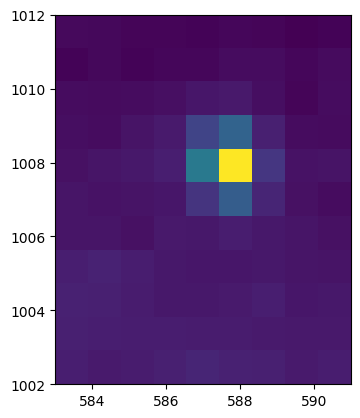

In [53]:

plt.imshow(cube[0,:,:].data[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 


/Users/nthom/opt/anaconda3/envs/py3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/nthom/.lightkurve/cache. Please move all the files in the legacy directory /Users/nthom/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<Axes: title={'center': 'Target ID: None, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

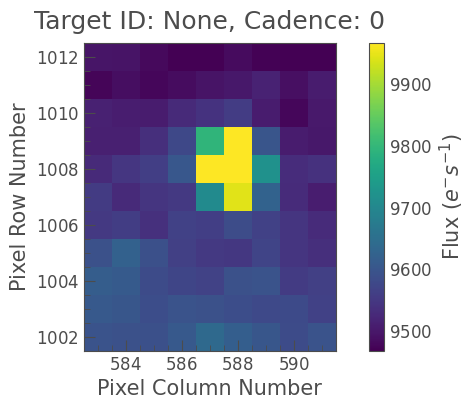

In [54]:
# TODO: I'll probably remove this, but it's a nice sanity check. What do you think?
import lightkurve as lk
tpf = lk.read(manifest['Local Path'][0])
tpf.plot()

Now that we can plot the data, let's take a closer look at the target star. First, we can identify the pixel location with the brightest flux. We can then use the pixel location to define a simple aperture, which for example could be used to extract a lightcurve.

In [56]:

brightest_time, brightest_row, brightest_col = np.where(cube.data == np.max(cube.data))
#brightest_time = brightest_times, brightest_row, brightest_col 
print(brightest_time, brightest_row, brightest_col)



[106] [6] [5]


In [82]:
# Get all time steps for the pixels containing the target star
target = cube[:, brightest_row[0]-1:brightest_row[0]+2, brightest_col[0]-1:brightest_col[0]+2] # Remember, this is [time, row, column]
target

📘 DataCube (3450, 3, 3), Uncertainty: True

In [84]:
targetlc = target.sum(axis=1)
targetlc

time_index  time          timecorr   time_       
0           2.459526e+06  -0.003259  2.459526e+06    83249.914062
1           2.459526e+06  -0.003258  2.459526e+06    84918.554688
2           2.459526e+06  -0.003257  2.459526e+06    86508.109375
3           2.459526e+06  -0.003257  2.459526e+06    87895.781250
4           2.459526e+06  -0.003256  2.459526e+06    88937.570312
                                                         ...     
3445        2.459551e+06  -0.000952  2.459551e+06     6235.246094
3446        2.459551e+06  -0.000951  2.459551e+06     6228.056152
3447        2.459551e+06  -0.000950  2.459551e+06     6228.932129
3448        2.459551e+06  -0.000950  2.459551e+06     6231.092285
3449        2.459551e+06  -0.000949  2.459551e+06     6227.060059
Length: 3450, dtype: float32


📉 DataSeries (3450,)

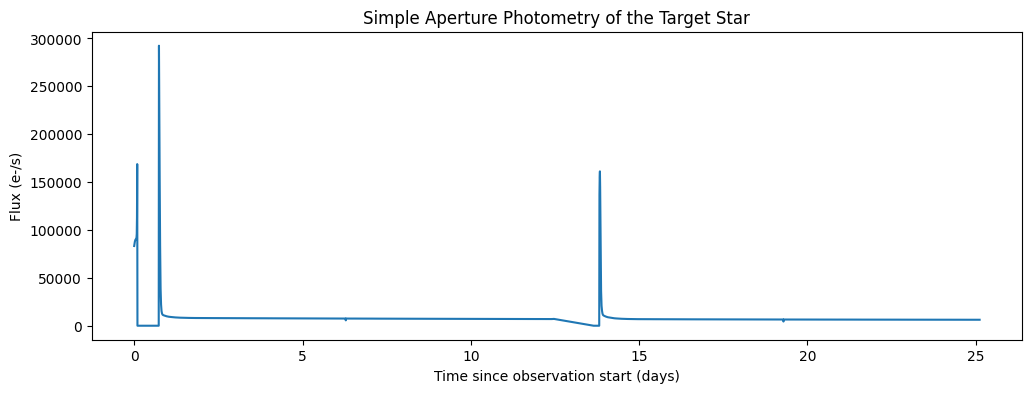

In [90]:
fig, ax = plt.subplots(1, figsize=(12,4))
ax.plot(targetlc.time - min(targetlc.time), targetlc.data)
ax.set_title("Simple Aperture Photometry of the Target Star")
ax.set_xlabel('Time since observation start (days)')
ax.set_ylabel('Flux (e-/s)')
plt.show()

Now we have made our own Simple Aperture Photometry lightcurve for the target star. You can see there are some large spikes in the data at the start and at the midpoint. These are due to scattered light at the beginning of each orbit. We leave it as an exercise to remove the scattered light trend by using the background pixels (see this [lightkurve tutorial](https://lightkurve.github.io/lightkurve/tutorials/2-creating-light-curves/2-1-cutting-out-tpfs.html) for more information). 

### 3.2 Binning

Often you may want to bin the data. For example, you may want to bin in the time dimension to reduce the noise to bring out features in the data or bin in the spatial dimension to visualize what your data at a lower resolution. The DataCube object makes this easy. In the example below, we first bine by time, then bin pixels togehter in one line of code. 

In [58]:
# TODO: note this is not a length of 690 (3450/5), so this must mean 3 bins were not 'full' 
cube.downsample(nframes=5, level="time").spatial_downsample(factor=2)

📘 DataCube (687, 5, 4), Uncertainty: True

### 3.3 - Other Properties

DataCube objects have other properties you can access directly. These include col, row, and uncertainty. Note col and row are the same for all images in the stack. However, the uncertainties match the dimensions of the data. 

In [59]:
cube.pixel_col.shape, cube.pixel_row.shape, cube.uncertainty.shape


((99,), (99,), (3450, 11, 9))

You can also perform math operations on the DataCube. For example, we could create a 2D image containing the median data for each pixel. Note this returns the median data as well as the associated uncertainties

In [60]:
cube.mean(axis=0) 

(array([[ 441.7092 ,  441.90225,  442.74725,  443.3073 ,  448.73166,
          447.50076,  445.8543 ,  446.03046,  445.97845],
        [ 442.98264,  445.3411 ,  445.21796,  443.34595,  444.92865,
          446.72693,  445.51782,  444.95996,  447.28983],
        [ 449.1061 ,  474.56668,  469.81662,  445.87985,  444.63474,
          446.6372 ,  445.31216,  445.6053 ,  446.59845],
        [ 453.32626,  511.95407,  485.99942,  448.07504,  445.7115 ,
          447.0069 ,  445.11334,  444.72174,  444.5894 ],
        [ 456.06757,  462.3282 ,  454.4368 ,  450.8118 ,  461.6276 ,
          474.29486,  458.18344,  445.43454,  443.7546 ],
        [ 452.08572,  448.93573,  451.87274,  470.7218 ,  612.4403 ,
          826.31006,  555.6611 ,  452.33835,  443.7974 ],
        [ 445.97244,  447.44986,  456.58432,  503.09467,  968.47644,
         2011.2655 ,  652.3894 ,  455.3011 ,  444.74472],
        [ 444.03137,  445.64905,  456.36105,  495.69156,  714.15045,
          924.2393 ,  541.06995,  451.7701

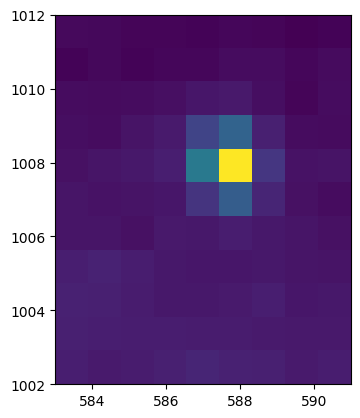

In [61]:
# Plot the mean value for each pixel
plt.imshow(cube[0,:,:].mean(axis=0)[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 

plt.show()


In [62]:
# by default, axis=None, which gives the mean of all data in all dimensions
cube.mean(axis=None)

(490.68353, Uncertainty(0.00184842))

In [63]:
# TODO: can't do cube.uncertainty.mean(). Is this fine? Yes, leave uncertainty math alone
cube.uncertainty.array.mean()

0.96991456

### 3.4 - BitwiseCubes

As mentioned in the introduction, BitwiseCube was developed to handle the [TESS](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) and [Kepler/K2](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/k2/_documents/MAST_Kepler_Archive_Manual_2020.pdf#page=18) quality masks. The quality flags are stored in a bitwise operation so that we can easily disentangle all flags attributed to a given time step. When 'adding' bitwise flags, for example when downsampling, we want BitwiseCubes to keep track of all flags that are triggered over the time step. Let's see how this looks in practice below. 

In [65]:
quality_flags = lcf[1].data['QUALITY']
print(quality_flags)
print(np.unique(quality_flags))

[128 128 128 ...   0   0   0]
[    0    32   128   164 16384 16416 16512]


We can see above that a number of quality flags can be found in this TPF. These include
- 0: No quality flag
- 32: Reaction Wheel desaturation Event
- 128: Manual Exclude. The cadence was excluded because of an anomaly
- 164: (128+32+4) Manual Exclude. The cadence was excluded because of an anomaly + Reaction Wheel desaturation Event + Spacecraft is in Coarse Point
- 16384: Bad Calibration Exclude (pipeline >= spoc-4.0.14)
- 16416: (16384 + 32) Bad Calibration Exclude + Reaction Wheel desaturation Event
- 16512: (16384 + 128) Bad Calibration Exclude + Manual Exclude due to an anomaly.

In [66]:
bitwise = lkdata.BitwiseSeries(data=quality_flags,
                       time_indices={'time':time + 2457000},
                          )
bitwise

📗 BitwiseSeries (3450,)

In [67]:
ds = lkdata.DataSeries(data=np.random.random(len(time)),
                       time_indices={'time':time + 2457000},
                          )
ds.downsample(nframes=5, level='time_index')

mid_index  indices                     time        
2.0        [0 1 2 3 4]                 2.459526e+06    3.122328
7.0        [5 6 7 8 9]                 2.459526e+06    2.879047
12.0       [10 11 12 13 14]            2.459526e+06    2.000026
17.0       [15 16 17 18 19]            2.459526e+06    2.331499
22.0       [20 21 22 23 24]            2.459526e+06    2.867625
                                                         ...   
3427.0     [3425 3426 3427 3428 3429]  2.459550e+06    2.286304
3432.0     [3430 3431 3432 3433 3434]  2.459551e+06    2.008093
3437.0     [3435 3436 3437 3438 3439]  2.459551e+06    1.605930
3442.0     [3440 3441 3442 3443 3444]  2.459551e+06    2.220116
3447.0     [3445 3446 3447 3448 3449]  2.459551e+06    2.165188
Length: 690, dtype: float64


📉 DataSeries (690,)

In [68]:
# If we 'sum' the bitwise set, we get a list of all individual flags that are found in the BitwiseSet
bitwise.sum()

BitSet {4, 32, 128, 16384}

In [69]:
# downsampling a BitwiseSeries gives the sum of all individual flags found in each bin. 

bitwise.downsample(level='time',nframes=5)

📗 BitwiseSeries (687,)

# 4 - Putting it all together with DataSet

Now that we understand the different classes in lkdata, let's try to put it all together. For example, a DataSeries can only contain one data array, but what if we want to tie multiple bits of data together? For example, we may want to track the [Simple Aperture Photometry (SAP) as well as the Pre-search Data Conditioning-SAP (PDCSAP)](https://heasarc.gsfc.nasa.gov/docs/tess/LightCurveFile-Object-Tutorial.html) so that if we manipulate the data (by downsampling or slicing) the operation is performed on both DataSets with one command. DataSets allow us to do this. They are also flexible enough to handle any of the different types of data products (DataSeries/Frame/Cube, BoolSeries/Frame/Cube, BitwiseSeries/Frame/Cube). Let's use our K2-18 data from Section 3 as an example. 

When defining a dataset, you need to specify the type of data products (data, boolean, or bitwise) you are including. If you do not specify, the DataSet will assume you will provide them in order (Data products, then Boolean products, then Bitwise products, and finally additional properties). 


In [70]:
# TODO: DataSet docstring is not clear with how DataSet init works. 
# TODO: how do aperturew get handled? 


lkdata.DataSet({'tpf':cube, 'quality':bitwise})



Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True, 'quality': 📗 BitwiseSeries (3450,)}
Bool Products:
{}
Bitwise Products:
{}
Properties:
[]

In [71]:
# if you don't specify the type of products, DataSet will assume these are defined in order. 
# Note that our bitwise products is wrongly classified as a Bool Product in this case. 
lkdata.DataSet({'tpf':cube}, {'quality':bitwise})


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{'quality': 📗 BitwiseSeries (3450,)}
Bitwise Products:
{}
Properties:
[]

In [72]:
# To be safe, it is always advised to specify the data type for each input. 
dset = lkdata.DataSet(data_products={'tpf':cube}, 
               bool_products={'quality_flag':bitwise.values >0},
               bitwise_products={'quality':bitwise},
               target='K2-18')
dset


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (3450,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (3450,)}
Properties:
['target']

In [73]:
# TODO: I expect there to be a describe_cube function like there is for the other products
dset.describe_set()

AttributeError: 'DataSet' object has no attribute 'describe_set'

In [74]:
# You can easily access the metadata by key
dset.target

'K2-18'

Now when performing operations such as slicing or downsampling, the operation will apply to every item contained in the DataSet. For example, if we want to bin by time, the downsample will apply to every product that has a time dimension. Spatial downsampling, on the other hand, will only apply to products that contain 3-D information (image data). Slicing is similar, where if you slices made in the time dimension happen for all data products, but row/column slices only happen on 3D data. 

In [98]:
# Note all data products have been downsampled in the time dimension
dset.downsample(nframes=2)


Data Products:
{'tpf': 📘 DataCube (1722, 11, 9), Uncertainty: False}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (1722,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (1722,)}
Properties:
['target']

In [99]:
dset.spatial_downsample(factor=2)



Data Products:
{'tpf': 📘 DataCube (3450, 5, 4), Uncertainty: False}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (3450,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (3450,)}
Properties:
['target']

In [100]:
# Slice by keeping every 5th time step
dset[::5, :,:]


Data Products:
{'tpf': 📘 DataCube (690, 11, 9), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (690,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (690,)}
Properties:
['target', 'columns']

In [101]:
# Keep the first 100 time steps, and the first two row/columns for any DataCube products.
dset[:100, :2,:2]


Data Products:
{'tpf': 📘 DataCube (100, 2, 2), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (100,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (100,)}
Properties:
['target', 'columns']

You can access a specific data product by name. This will return the underlying DataSeries, SeriesCollection, or DataCube. 

In [102]:
dset[:100, :2,:2]['tpf']

📘 DataCube (100, 2, 2), Uncertainty: True

# Conclusion

lkdata provides a backbone to quickly handle timeseries-like data. As lkdata is built on pandas DataFrames, transformations such as slicing and binning are easily (and quickly) accomplished. 

This tutorial covered the basic features of lkdata, including the types of data products available as well as the types of manipulations you can do with that data. It also gave an introduction to how this can be done using real timeseries data from TESS. These examples serve as building blocks to construct larger and more powerful DataSets. 

The latest release of lighkurve builds upon these basic structures. While lightkurve handles setting up the DataSets for TESS/Kepler/K2 data products for users, this tutorial provides the background to understand the basic structure and functionality that can be used. 